# 05. Terrain Derivatives
Generate slope, aspect, hillshade, and other terrain metrics from a Digital Elevation Model (DEM).

In [1]:
import curaster
import os

# We will use one of our test files as a mock DEM.
input_file = "../build/benchmark_data/test_M_4096x4096.tif"
output_file = "terrain_derivatives.tif"

## Compute Terrain Metrics
We select multiple metrics. The output will be a multi-band GeoTIFF, with each requested metric as a separate band.

In [2]:
%%time
metrics = ["slope", "aspect", "hillshade", "tpi", "roughness"]

chain = curaster.open(input_file) \
    .algebra("B1") \
    .terrain(metrics=metrics, unit="degrees", sun_azimuth=315.0, sun_altitude=45.0, method="horn")

chain.save_local(output_file, verbose=True)
print(f"Saved {len(metrics)} terrain bands to {output_file}")

0Saved 5 terrain bands to terrain_derivatives.tif
CPU times: user 10 s, sys: 1.04 s, total: 11.1 s
Wall time: 11.1 s
...10...20...30...40...50...60...70...80...90...100 - done.


## Load and Inspect Multi-band Result
We can also load terrain metrics directly into memory — `to_memory()` returns a 3D NumPy array `[bands, height, width]`.

Result shape: (2, 4096, 4096), bands=2


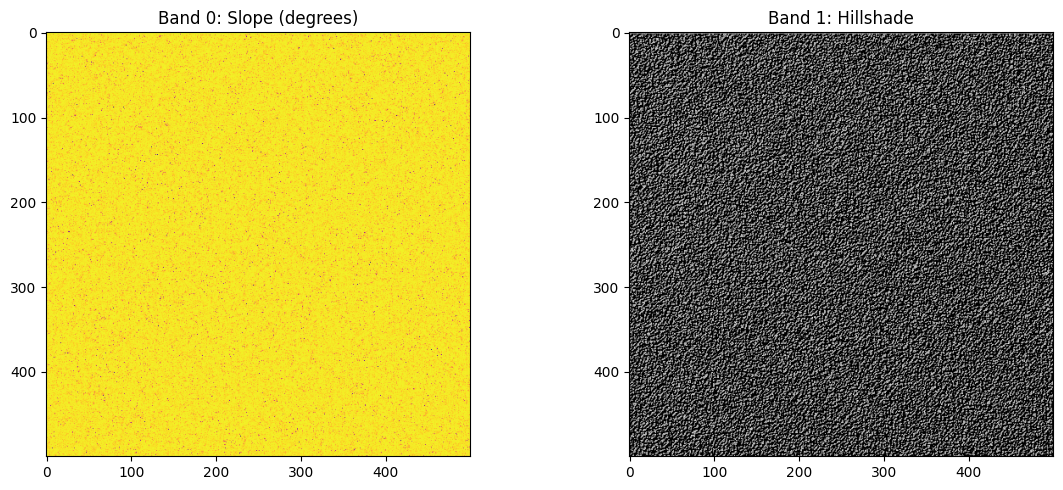

In [3]:
import matplotlib.pyplot as plt

result = curaster.open(input_file) \
    .algebra("B1") \
    .terrain(metrics=["slope", "hillshade"], unit="degrees") \
    .to_memory()

arr = result.data()  # shape: [bands, height, width]
print(f"Result shape: {arr.shape}, bands={result.bands}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(arr[0, :500, :500], cmap="plasma"); axes[0].set_title("Band 0: Slope (degrees)")
axes[1].imshow(arr[1, :500, :500], cmap="gray");   axes[1].set_title("Band 1: Hillshade")
plt.tight_layout()
plt.show()